<a href="https://colab.research.google.com/github/RodrigoLMarques/calculo-numerico-unifesp/blob/main/atividade_2/cn_atividade2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cálculo Numérico - Atividade prática 2

## Identificação e Divisão de Tarefas

Nome: Luan Groppo Viana

RA: 177103

Realizou:

Nome: Rodrigo Lopes Marques

RA: 180385

Realizou:

Nome: Leonardo Arantes Lopes Macedo

RA: 176558

Realizou:

Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308
dt=0.001, float32: 400 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 400 passos sem overflow.
dt=0.002, float64: 400 passos sem overflow.


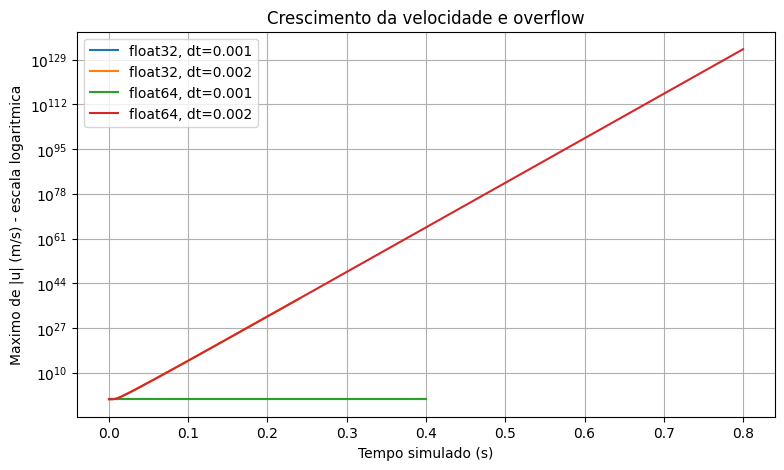

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def simular(dt, tipo=np.float32, passos=400, pontos=21):
    """Simula difusao de velocidade e detecta falhas."""
    H = 0.01
    nu = 1e-4
    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    # Coeficientes no tipo numerico escolhido.
    r = tipo(nu * dt / dy**2)
    dois = tipo(2)

    # Fluido parado e placa em y=0 em movimento.
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None

    # Transforma avisos numericos em excecoes.
    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()
                # Atualiza o interior e preserva as paredes.
                novo[1:-1] = (
                    u[1:-1]
                    + r * (
                        u[2:] - dois * u[1:-1] + u[:-2]
                    )
                )
            except FloatingPointError as erro:
                falha = passo
                print(
                    f"dt={dt}, {tipo.__name__}: "
                    f"falha no passo {passo}, "
                    f"t={passo * dt:.4f} s - {erro}"
                )
                break

            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:
        print(
            f"dt={dt}, {tipo.__name__}: "
            f"{passos} passos sem overflow."
        )

    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "r": float(r),
        "falha": falha,
    }


print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)

resultados = {}
for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = simular(dt, tipo)

plt.figure(figsize=(9, 5))
for nome, resultado in resultados.items():
    plt.semilogy(
        resultado["tempos"],
        resultado["maximos"],
        label=nome
    )
plt.xlabel("Tempo simulado (s)")
plt.ylabel("Maximo de |u| (m/s) - escala logaritmica")
plt.title("Crescimento da velocidade e overflow")
plt.grid(True)
plt.legend()
plt.show()

## 1.
Calcule ∆y, ∆tmax e r para os casos A e B. Classifique cada caso como estável ou instável antes de executar o programa.
$$
\Delta y = \frac{H}{21-1}
$$

$$
\Delta t_{max} = \frac{\Delta y^2}{2v}
$$

$$
r = \dfrac{v \Delta t}{\Delta y^2}
$$

###Resposta:
No caso A e B ∆y e ∆tmax são os mesmos, a diferença é

## 2. Detecção de overflow.

Com a excução dos 4 testes, obtivemos como output:
```
dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add
```

Dessa forma, podemos montar a tabela:

### Tabela dos testes

| Tipo numérico | Δt (s) | r | Estável? (r ≤ 0,5) | Overflow | Iteração da falha | t da falha (s) | max \|u\| final |
|---|---|---|---|---|---|---|---|
| float32 | 0,001 | 0,40 | sim | não | — | — | 1,0000e+00 |
| float32 | 0,002 | 0,80 | não | sim | 121 | 0,2420 | 1,6659e+38 |
| float64 | 0,001 | 0,40 | sim | não | — | — | 1,0000e+00 |
| float64 | 0,002 | 0,80 | não | sim | 917 | 1,8340 | 4,7434e+307 |


## 4. Capacidade de representação.

A mudança de tipo numérico não eliminou a instabilidade, apenas aumentou o número de iterações até a falha. Com o float32 falhou na iteração 121, e com float64 falhou na iteração 917, com uma diferença de 796 passos.

TODO: da para responder sobre a instabilidade melhor, matematicamente